In [4]:
#Different Riemann function, Execution Time : 20 Min Approx

In [ ]:
import os
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from scipy.linalg import sqrtm
from sklearn.covariance import LedoitWolf
import matplotlib.pyplot as plt

np.random.seed(42)

# === PARAMETERS ===
# main_folder_path = "/home/ubuntu/Documents/4_40 HZ Bandpass/13 Subjects Hindi Preprocessed"
main_folder_path = r"C:\Tanmay\6thSem\FYP\code\Hindi KNN\13 Subjects Hindi Preprocessed.zip"
selected_words = ["PAIN", "LIGHT"]
window_size = 256
stride = 128

# === LOAD & PREPARE DATA ===
data_list = []
subject_folders = [f for f in os.listdir(main_folder_path) if os.path.isdir(os.path.join(main_folder_path, f))]

for subject in subject_folders:
    subject_path = os.path.join(main_folder_path, subject)
    files = [f for f in os.listdir(subject_path) if f.endswith("_labeled_EEG_data.csv")]
    for file in files:
        df = pd.read_csv(os.path.join(subject_path, file))
        df["Subject_ID"] = subject
        data_list.append(df)

df = pd.concat(data_list, ignore_index=True)
df = df[df["Label"].isin(selected_words)]

# Encode labels
label_encoder = LabelEncoder()
df["Label"] = label_encoder.fit_transform(df["Label"])
print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# === EPOCHING ===
eeg_data = df.iloc[:, 1:33].values  # 32-channel EEG
labels = df["Label"].values

epochs = []
epoch_labels = []

for i in range(0, len(eeg_data) - window_size + 1, stride):
    if len(set(df["Label"].iloc[i:i + window_size])) == 1:
        epoch = eeg_data[i:i + window_size].T  # shape (32, 256)
        epochs.append(epoch)
        epoch_labels.append(labels[i])

epochs = np.array(epochs)
epoch_labels = np.array(epoch_labels)
num_epochs = len(epochs)

# === COMPUTE REGULARIZED COVARIANCE MATRICES ===
cov_estimator = LedoitWolf()
cov_matrices = [cov_estimator.fit(epoch.T).covariance_ for epoch in epochs]  # transpose for (samples, channels)

# === RIEMANNIAN DISTANCE FUNCTION (trace-based) ===
def riemannian_distance(psd1, psd2):
    trace_term = np.trace(psd1 + psd2 - 2 * sqrtm(psd1 @ psd2))
    return np.sqrt(trace_term.real)  # ensure real number

# === COMPUTE DISTANCE MATRIX ===
riemannian_distances = np.zeros((num_epochs, num_epochs))

for i in range(num_epochs):
    for j in range(i + 1, num_epochs):
        dist = riemannian_distance(cov_matrices[i], cov_matrices[j])
        riemannian_distances[i, j] = dist
        riemannian_distances[j, i] = dist

# === TRAIN-TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(riemannian_distances, epoch_labels, test_size=0.3, random_state=42)

# === CUSTOM KNN CLASSIFIER ===
def knn_classifier(train_data, train_labels, test_data_row, k):
    distances = np.linalg.norm(train_data - test_data_row, axis=1)
    nearest_neighbors = np.argsort(distances)[:k]
    neighbor_labels = train_labels[nearest_neighbors]
    most_common_label = Counter(neighbor_labels).most_common(1)[0][0]
    return most_common_label

# === EVALUATE K FROM 1 to 99 ===
accuracies = []

for k in range(1, 100):
    predicted_labels = []
    for i in range(len(X_test)):
        pred = knn_classifier(X_train, y_train, X_test[i], k)
        predicted_labels.append(pred)
    acc = metrics.accuracy_score(y_test, predicted_labels)
    accuracies.append(acc)

# === BEST K ===
best_k = np.argmax(accuracies) + 1
best_acc = accuracies[best_k - 1]
print(f"Best k: {best_k} | Accuracy: {best_acc:.4f}")

# === PLOT ===
plt.figure(figsize=(10, 4))
plt.plot(range(1, 100), accuracies, marker='o')
plt.title('Riemannian KNN Accuracy vs k (Trace-based Distance)')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()


: 

In [8]:
# === FINAL PREDICTIONS USING BEST K ===
final_predictions = []
for i in range(len(X_test)):
    pred = knn_classifier(X_train, y_train, X_test[i], best_k)
    final_predictions.append(pred)

# === METRICS ===
accuracy = metrics.accuracy_score(y_test, final_predictions)
precision = metrics.precision_score(y_test, final_predictions)
recall = metrics.recall_score(y_test, final_predictions)
f1 = metrics.f1_score(y_test, final_predictions)
conf_matrix = metrics.confusion_matrix(y_test, final_predictions)
class_report = metrics.classification_report(y_test, final_predictions, target_names=label_encoder.classes_)

print(f"\n--- Evaluation Metrics for Best k = {best_k} ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)



--- Evaluation Metrics for Best k = 1 ---
Accuracy:  0.6358
Precision: 0.6447
Recall:    0.6522
F1 Score:  0.6484

Confusion Matrix:
[[201 124]
 [120 225]]

Classification Report:
              precision    recall  f1-score   support

       LIGHT       0.63      0.62      0.62       325
        PAIN       0.64      0.65      0.65       345

    accuracy                           0.64       670
   macro avg       0.64      0.64      0.64       670
weighted avg       0.64      0.64      0.64       670



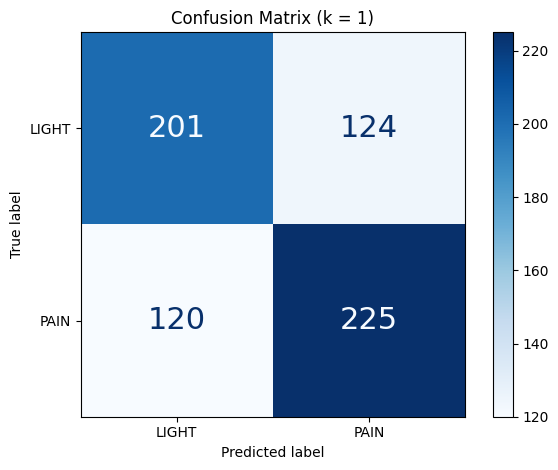

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# === Predict Using Best k ===
final_predictions = []
for i in range(len(X_test)):
    pred = knn_classifier(X_train, y_train, X_test[i], best_k)
    final_predictions.append(pred)

# === Confusion Matrix ===
cm = confusion_matrix(y_test, final_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (k = {best_k})')
plt.tight_layout()
# 🔥 Increase only the numbers inside the matrix
for text in disp.text_.ravel():
    text.set_fontsize(22)   # Change size as needed
plt.show()
